In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

In [2]:
# 1.加载数据及预处理
# 加载数据
data = load_breast_cancer()
X = data.data  # (569, 30)
y = data.target  # (569,)

print(f"原始数据形状: X={X.shape}, y={y.shape}")
print(f"类别分布: 类别0={np.sum(y==0)}, 类别1={np.sum(y==1)}")
print(f"特征名称: {data.feature_names[:5]}...")

# 划分训练集和测试集 (80% 训练, 20% 测试)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"训练集形状: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"测试集形状: X_test={X_test.shape}, y_test={y_test.shape}")

# 标准化特征（重要：使梯度下降更稳定）
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("特征已标准化（均值=0，标准差=1）")

原始数据形状: X=(569, 30), y=(569,)
类别分布: 类别0=212, 类别1=357
特征名称: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']...
训练集形状: X_train=(455, 30), y_train=(455,)
测试集形状: X_test=(114, 30), y_test=(114,)
特征已标准化（均值=0，标准差=1）


In [3]:
# 2.实现sigmoid函数
def sigmoid(z):
    # 处理数值稳定性问题
    z = np.clip(z, -500, 500)  # 防止溢出
    return 1 / (1 + np.exp(-z))

# 测试sigmoid函数
print(f"sigmoid(0) = {sigmoid(0)}")

sigmoid(0) = 0.5


In [4]:
# 3.实现预测概率函数
def predict_probability(X, w, b):
    z = np.dot(X, w) + b
    p = sigmoid(z)
    return p

In [5]:
# 4.实现二元交叉熵损失函数
def binary_cross_entropy(y_true, y_pred, eps=1e-7):
    y_pred = np.clip(y_pred, eps, 1 - eps)
    loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return loss

In [6]:
# 5.实现梯度计算函数
def compute_gradients(X, y_true, y_pred):
    n_samples = X.shape[0]

    error = y_pred - y_true

    dw = (1/n_samples) * np.dot(X.T, error)
    db = (1/n_samples) * np.sum(error)

    return dw, db

In [7]:
class LogisticRegression:
    def __init__(self, learning_rate=0.01, n_iterations=1000, verbose=True):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.verbose = verbose
        self.w = None
        self.b = None
        self.loss_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # 初始化参数（使用小的随机值）
        self.w = np.random.randn(n_features) * 0.01
        self.b = 0.0

        # 训练循环
        for i in range(self.n_iterations):
            # 前向传播：计算预测概率
            y_pred = predict_probability(X, self.w, self.b)

            # 计算损失
            loss = binary_cross_entropy(y, y_pred)
            self.loss_history.append(loss)

            # 计算梯度
            dw, db = compute_gradients(X, y, y_pred)

            # 更新参数（梯度下降）
            self.w -= self.learning_rate * dw
            self.b -= self.learning_rate * db

            # 打印训练进度
            if self.verbose and (i % 100 == 0 or i == self.n_iterations - 1):
                print(f"Iteration {i:4d}/{self.n_iterations}, Loss: {loss:.6f}")

    def predict_probability(self, X):
        return predict_probability(X, self.w, self.b)

    def predict(self, X, threshold=0.5):
        probabilities = self.predict_probability(X)
        return (probabilities >= threshold).astype(int)

    def score(self, X, y):
        y_pred = self.predict(X)
        accuracy = np.mean(y_pred == y)
        return accuracy


In [8]:
# 6.实现训练循环
# 设置超参数
lr = 0.1
n_iter = 1000

print(f"\n超参数设置:")
print(f"  学习率: {lr}")
print(f"  迭代次数: {n_iter}")

# 创建并训练模型
model = LogisticRegression(
    learning_rate=lr,
    n_iterations=n_iter,
    verbose=True
)

model.fit(X_train_scaled, y_train)


超参数设置:
  学习率: 0.1
  迭代次数: 1000
Iteration    0/1000, Loss: 0.697122
Iteration  100/1000, Loss: 0.098142
Iteration  200/1000, Loss: 0.079983
Iteration  300/1000, Loss: 0.072153
Iteration  400/1000, Loss: 0.067542
Iteration  500/1000, Loss: 0.064407
Iteration  600/1000, Loss: 0.062092
Iteration  700/1000, Loss: 0.060287
Iteration  800/1000, Loss: 0.058826
Iteration  900/1000, Loss: 0.057611
Iteration  999/1000, Loss: 0.056587


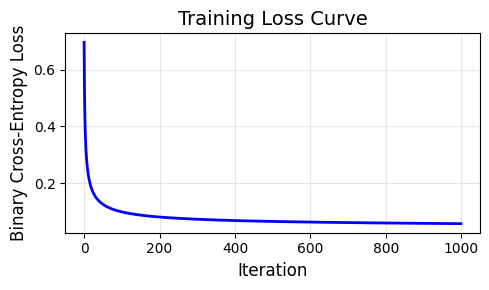

In [11]:
# 7.画出Loss曲线
plt.figure(figsize=(5, 3))
plt.plot(model.loss_history, 'b-', linewidth=2)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Binary Cross-Entropy Loss', fontsize=12)
plt.title('Training Loss Curve', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# 8.在计算准确率
# 训练集评估
train_accuracy = model.score(X_train_scaled, y_train)
print(f"训练集准确率: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")

# 测试集评估
test_accuracy = model.score(X_test_scaled, y_test)
print(f"测试集准确率: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

训练集准确率: 0.9890 (98.90%)
测试集准确率: 0.9737 (97.37%)
